Pytorch-Unet

In [ ]:
"""
!pip install -q condacolab
import condacolab
condacolab.install()
import condacolab
condacolab.check()
condacolab.install_miniconda()
!conda install python=3.11
"""

'\n!pip install -q condacolab\nimport condacolab\ncondacolab.install()\nimport condacolab\ncondacolab.check()\ncondacolab.install_miniconda()\n!conda install python=3.11\n'

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!wget https://repo.anaconda.com/miniconda/Miniconda3-latest-Linux-x86_64.sh
!bash Miniconda3-latest-Linux-x86_64.sh -b -f -p /usr/local
!conda tos accept --override-channels --channel https://repo.anaconda.com/pkgs/main
!conda tos accept --override-channels --channel https://repo.anaconda.com/pkgs/r
!conda create -n unetenv python=3.11 -y
!source activate unetenv && python --version
!source activate unetenv && conda install pytorch -y
!source activate unetenv && conda install torchvision -y
!git clone https://github.com/milesial/Pytorch-UNet.git
%cd Pytorch-UNet
!source activate unetenv && pip install -r requirements.txt
!source activate unetenv && pip install --upgrade wandb
!source activate unetenv && pip install matplotlib-inline==0.1.7
!source activate unetenv && pip install ipython

--2026-08-12 14:10:56--  https://repo.anaconda.com/miniconda/Miniconda3-latest-Linux-x86_64.sh
Resolving repo.anaconda.com (repo.anaconda.com)... 104.16.191.158, 104.16.32.241, 2606:4700::6810:bf9e, ...
Connecting to repo.anaconda.com (repo.anaconda.com)|104.16.191.158|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 197272282 (188M) [application/octet-stream]
Saving to: ‘Miniconda3-latest-Linux-x86_64.sh’

Miniconda3-latest-L 100%[===================>] 188.13M   244MB/s    in 0.8s    

2026-08-12 14:10:57 (244 MB/s) - ‘Miniconda3-latest-Linux-x86_64.sh’ saved [197272282/197272282]

PREFIX=/usr/local
Unpacking bootstrapper...
Unpacking payload...

Installing base environment...

Preparing transaction: ...working... done
Executing transaction: ...working... done
installation finished.
    You currently have a PYTHONPATH environment variable set. This may cause
    unexpected behavior when running the Python interpreter in Miniconda3.
    For best results, please

In [3]:
!cp /content/drive/MyDrive/research/ML-OCT_datasets/oct5k_prepared/exp1/converted_img/* /content/Pytorch-UNet/data/imgs

In [4]:
!cp /content/drive/MyDrive/research/ML-OCT_datasets/oct5k_prepared/exp1/test_msk/* /content/Pytorch-UNet/data/masks

In [ ]:
!source activate unetenv && python train.py --epochs 10 --classes 6

INFO: Using device cpu
INFO: Network:
	3 input channels
	6 output channels (classes)
	Transposed conv upscaling
INFO: Creating dataset with 307 examples
INFO: Scanning mask files to determine unique values
  0% 0/307 [00:00<?, ?it/s]
INFO: Creating dataset with 307 examples
INFO: Scanning mask files to determine unique values
100% 307/307 [00:00<00:00, 320.92it/s]
INFO: Unique mask values: [0, 1, 2, 3, 4, 5]
wandb: WARNING The anonymous setting has no effect and will be removed in a future version.
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice: 2
wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter: 
wandb: No netrc file found, 

In [ ]:
!source activate unetenv && python predict.py -h

usage: predict.py [-h] [--model FILE] --input INPUT [INPUT ...]
                  [--output OUTPUT [OUTPUT ...]] [--viz] [--no-save]
                  [--mask-threshold MASK_THRESHOLD] [--scale SCALE]
                  [--bilinear] [--classes CLASSES]

Predict masks from input images

options:
  -h, --help            show this help message and exit
  --model FILE, -m FILE
                        Specify the file in which the model is stored
  --input INPUT [INPUT ...], -i INPUT [INPUT ...]
                        Filenames of input images
  --output OUTPUT [OUTPUT ...], -o OUTPUT [OUTPUT ...]
                        Filenames of output images
  --viz, -v             Visualize the images as they are processed
  --no-save, -n         Do not save the output masks
  --mask-threshold MASK_THRESHOLD, -t MASK_THRESHOLD
                        Minimum probability value to consider a mask pixel
                        white
  --scale SCALE, -s SCALE
                        Scale factor for the 

In [ ]:
!source activate unetenv && python predict.py -m /content/Pytorch-UNet/checkpoints/checkpoint_epoch10.pth -i /content/drive/MyDrive/research/ML-OCT_datasets/oct5k_prepared/exp1/converted_valid_img/0000.png -o val0000_out.png --classes 6

INFO: Loading model /content/Pytorch-UNet/checkpoints/checkpoint_epoch10.pth
INFO: Using device cuda
INFO: Model loaded!
INFO: Predicting image /content/drive/MyDrive/research/ML-OCT_datasets/oct5k_prepared/exp1/converted_valid_img/0000.png ...
INFO: Mask saved to val0000_out.png


In [ ]:
import cv2
import matplotlib.pyplot as plt


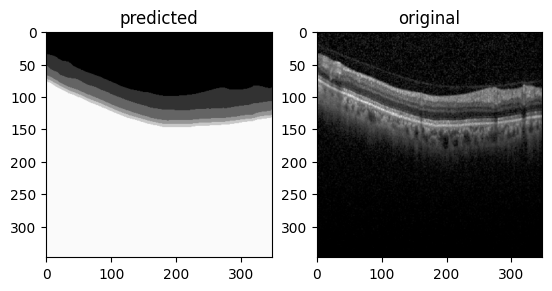

In [ ]:
out = cv2.imread("val0000_out.png")
out=out*50

plt.subplot(121)
plt.imshow(out)
plt.title("predicted")

original = cv2.imread("/content/drive/MyDrive/research/ML-OCT_datasets/oct5k_prepared/exp1/converted_valid_img/0000.png")

plt.subplot(122)
plt.imshow(original)
plt.title("original")
plt.show()

In [ ]:
from torchvision.utils import draw_segmentation_masks
from torchvision.io import read_image

In [ ]:
output = read_image("val0000_out.png")
image = read_image("/content/drive/MyDrive/research/ML-OCT_datasets/oct5k_prepared/exp1/converted_valid_img/0000.png")

img_w_msk = draw_segmentation_masks(image, output)
plt.imshow(img_w_msk)
plt.show()


ValueError: The masks must be of dtype bool. Got torch.uint8